# Eksperimen 2: Filtering, Smoothing, & Normalisasi Tensor
Notebook ini digunakan untuk menguji pipeline pra-pemrosesan data pose skeleton yang diimplementasikan di `preprocess.py`.

**Pipeline yang dijalankan:**
1. **Filter & Clean** — Menghapus koordinat dengan confidence rendah dan interpolasi linear.
2. **Smooth** — Median Filter temporal untuk mengurangi jitter.
3. **Spatial Normalize** — Translasi ke mid-hip dan scaling berdasarkan panjang torso.
4. **Temporal Resample** — Resampling data menjadi tepat 64 frame.

### 1. Import Library & Konfigurasi Path

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt

# Tambahkan direktori src/ ke Python path
sys.path.insert(0, os.path.abspath("../src"))

from data.preprocess import DataPreprocessor

print("Import berhasil.")

Import berhasil.


### 2. Definisi Path File

In [2]:
NPY_INPUT_PATH = "../data/processed/sample_video_pose.npy"
NPY_OUTPUT_PATH = "../data/processed/sample_video_tensor.npy"

if not os.path.exists(NPY_INPUT_PATH):
    print("[PERINGATAN] File input tidak ditemukan. Jalankan Notebook 01 terlebih dahulu.")
else:
    raw_array = np.load(NPY_INPUT_PATH)
    print(f"[OK] File ditemukan. Shape asli: {raw_array.shape}")

[OK] File ditemukan. Shape asli: (150, 33, 4)


### 3. Inisialisasi & Eksekusi Preprocessing

In [3]:
preprocessor = DataPreprocessor(
    visibility_threshold=0.3,
    nan_frame_ratio=0.30,
    max_interp_gap=5,
    median_kernel=3,
    target_frames=64
)

# Jalankan pipeline
tensor = preprocessor.process(NPY_INPUT_PATH, NPY_OUTPUT_PATH)

print(f"\nShape Akhir Tensor: {tensor.shape} (Diharapkan: 64, 33, 3)")

[PROSES] File dimuat: ../data/processed/sample_video_pose.npy
         Shape awal: (150, 33, 4)

[Step 2.2] Filter & Clean ...
  [filter_and_clean] Frame dihapus (>30% NaN): 2
  [filter_and_clean] Frame tersisa: 148

[Step 2.3] Smooth (Median Filter) ...
  [smooth_data] Median filter diterapkan (kernel=3) → shape: (148, 33, 4)

[Step 2.4] Spatial Normalize ...
  [spatial_normalize] Translasi & scaling selesai → shape: (148, 33, 3)
  [spatial_normalize] Rata-rata panjang torso: 0.2195

[Step 2.5] Temporal Resample ...
  [temporal_resample] 148 frame → 64 frame selesai → shape: (64, 33, 3)

[SELESAI] Tensor akhir shape: (64, 33, 3)
[SELESAI] Disimpan ke       : ../data/processed/sample_video_tensor.npy

Shape Akhir Tensor: (64, 33, 3) (Diharapkan: 64, 33, 3)


d:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC\src\data\preprocess.py:293: UserWarning:   [filter_and_clean] 2583 nilai NaN tersisa setelah interpolasi (gap > 5 frame). Diganti dengan 0.
  data = self.filter_and_clean(data)


### 4. Visualisasi Perbandingan (Sanity Check)

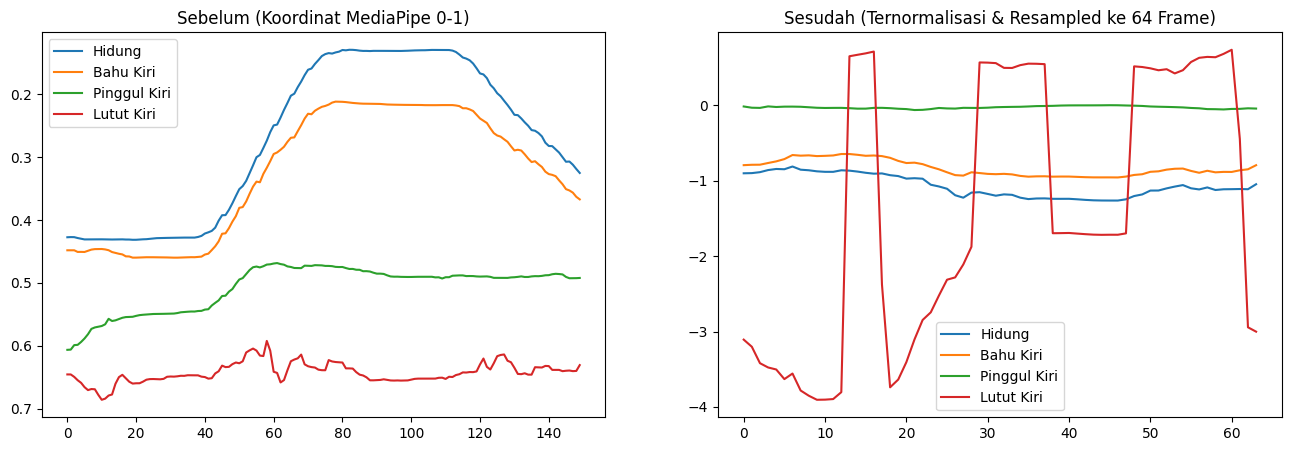

In [4]:
LANDMARK_LABELS = {0: "Hidung", 11: "Bahu Kiri", 23: "Pinggul Kiri", 25: "Lutut Kiri"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot Data Mentah
for idx, label in LANDMARK_LABELS.items():
    axes[0].plot(raw_array[:, idx, 1], label=label)
axes[0].invert_yaxis()
axes[0].set_title("Sebelum (Koordinat MediaPipe 0-1)")
axes[0].legend()

# Plot Data Ternormalisasi
for idx, label in LANDMARK_LABELS.items():
    axes[1].plot(tensor[:, idx, 1], label=label)
axes[1].set_title("Sesudah (Ternormalisasi & Resampled ke 64 Frame)")
axes[1].legend()

plt.show()

### 5. Inspeksi Statistik & Verifikasi Mid-Hip

In [5]:
mid_hip_verify = (tensor[:, 23, :] + tensor[:, 24, :]) / 2.0
print(f"Rata-rata koordinat Mid-Hip (Seharusnya mendekati 0):")
print(f"X: {mid_hip_verify[:,0].mean():.6f}, Y: {mid_hip_verify[:,1].mean():.6f}, Z: {mid_hip_verify[:,2].mean():.6f}")

Rata-rata koordinat Mid-Hip (Seharusnya mendekati 0):
X: -0.000000, Y: -0.000000, Z: 0.000000
